# Exploratory Data Analysis

## Project

E-Commerce Sales Intelligence Platform

### Objective

Analyze customer behavior, sales performance, delivery operations, and seller performance to generate actionable business insights.

In [14]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load data
data_path = Path("../data/processed")

master_df = pd.read_csv(
    data_path / "master_analytics_table.csv",
    parse_dates=[
        "shipping_limit_date",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

# Quick verification
master_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,seller_zip_code_prefix,seller_city,seller_state,total_payment_value,payment_installments,payment_methods,review_score,review_count,item_revenue,freight_percentage
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,27277,volta redonda,SP,72.19,2.0,1.0,5.0,1.0,72.19,0.225637
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,3471,sao paulo,SP,259.83,3.0,1.0,4.0,1.0,259.83,0.083076
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,37564,borda da mata,MG,216.87,5.0,1.0,5.0,1.0,216.87,0.089799
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,14403,franca,SP,25.78,2.0,1.0,4.0,1.0,25.78,0.984604
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,87900,loanda,PR,218.04,3.0,1.0,5.0,1.0,218.04,0.090745


In [15]:
kpi_summary = {
    "Total Revenue": master_df["item_revenue"].sum(),
    "Total Orders": master_df["order_id"].nunique(),
    "Total Customers": master_df["customer_unique_id"].nunique(),
    "Total Sellers": master_df["seller_id"].nunique(),
    "Average Order Value": (
        master_df.groupby("order_id")["item_revenue"].sum().mean()
    ),
    "Average Review Score": master_df["review_score"].mean()
}

kpi_df = pd.DataFrame(
    kpi_summary.items(),
    columns=["Metric", "Value"]
)

kpi_df

,Metric,Value
0,Total Revenue,1.584355e+07
1,Total Orders,9.866600e+04
2,Total Customers,9.542000e+04
3,Total Sellers,3.095000e+03
4,Average Order Value,1.605776e+02
5,Average Review Score,4.033128e+00


In [16]:
kpi_df = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Total Sellers",
        "Average Order Value",
        "Average Review Score"
    ],
    "Value": [
        f"${kpi_summary['Total Revenue']:,.2f}",
        f"{kpi_summary['Total Orders']:,}",
        f"{kpi_summary['Total Customers']:,}",
        f"{kpi_summary['Total Sellers']:,}",
        f"${kpi_summary['Average Order Value']:,.2f}",
        f"{kpi_summary['Average Review Score']:.2f}"
    ]
})

kpi_df

,Metric,Value
0,Total Revenue,"$15,843,553.24"
1,Total Orders,"98,666"
2,Total Customers,"95,420"
3,Total Sellers,"3,095"
4,Average Order Value,$160.58
5,Average Review Score,4.03


# Executive Summary

## Initial Findings

The platform processed over **99,000 orders** from nearly **100,000 customers**, generating millions in revenue.



In [17]:
category_revenue = (
    master_df
    .groupby("product_category_name_english", as_index=False)
    .agg(
        Total_Revenue=("item_revenue", "sum"),
        Orders=("order_id", "nunique")
    )
    .sort_values("Total_Revenue", ascending=False)
)

category_revenue.head(10)

,product_category_name_english,Total_Revenue,Orders
43,health_beauty,1441248.07,8836
70,watches_gifts,1305541.61,5624
7,bed_bath_table,1241681.72,9417
65,sports_leisure,1156656.48,7720
15,computers_accessories,1059272.40,6689
39,furniture_decor,902511.79,6449
49,housewares,778397.77,5884
20,cool_stuff,719329.95,3632
5,auto,685384.32,3897
42,garden_tools,584219.21,3518


In [18]:
category_revenue["Total_Revenue"] = (
    category_revenue["Total_Revenue"]
    .round(2)
)

category_revenue.head(10)

,product_category_name_english,Total_Revenue,Orders
43,health_beauty,1441248.07,8836
70,watches_gifts,1305541.61,5624
7,bed_bath_table,1241681.72,9417
65,sports_leisure,1156656.48,7720
15,computers_accessories,1059272.40,6689
39,furniture_decor,902511.79,6449
49,housewares,778397.77,5884
20,cool_stuff,719329.95,3632
5,auto,685384.32,3897
42,garden_tools,584219.21,3518


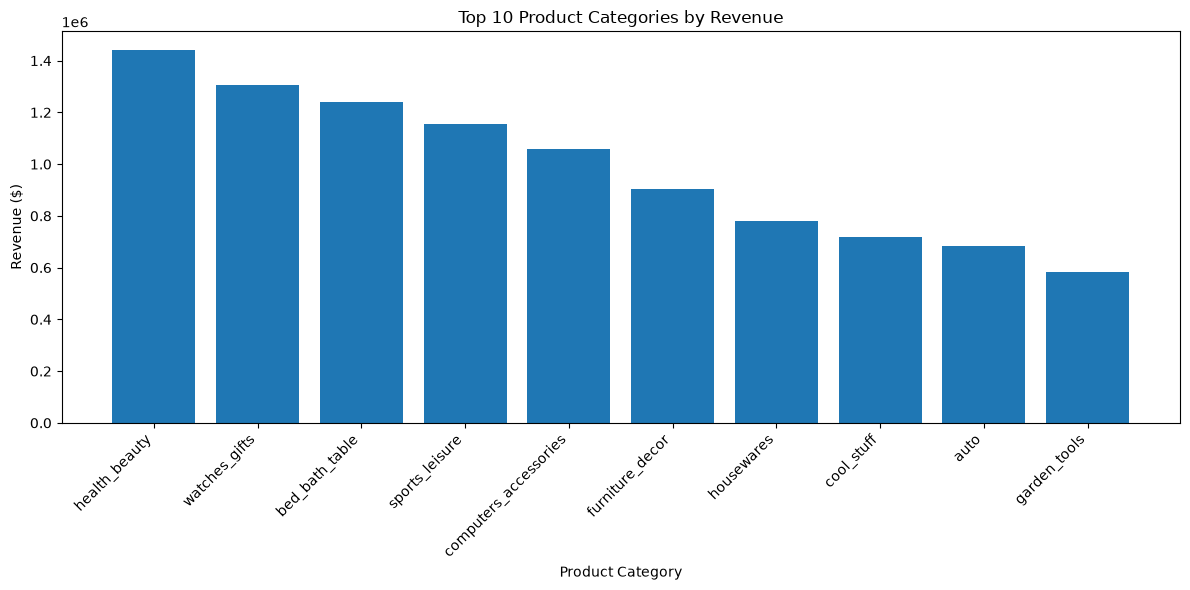

In [19]:
top10 = category_revenue.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top10["product_category_name_english"],
    top10["Total_Revenue"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Product Category")
plt.ylabel("Revenue ($)")
plt.title("Top 10 Product Categories by Revenue")

plt.tight_layout()
plt.show()

## Business Insight

The Health & Beauty category generated the highest total revenue, followed by Watches & Gifts and Bed, Bath & Table.

These categories appear to be the primary revenue drivers for the business. Management may consider prioritizing inventory availability, promotional campaigns, and supplier relationships for these categories to maintain or increase sales performance.

However, high revenue alone does not necessarily indicate high profitability or customer satisfaction. Additional analyses involving profit margins, delivery performance, and customer review scores are needed before making strategic decisions.

#Business Question
Do customers give lower ratings when deliveries are late?

In [20]:
master_df[["is_late_delivery", "review_score"]].head()

,is_late_delivery,review_score
0,False,5.0
1,False,4.0
2,False,5.0
3,False,4.0
4,False,5.0


In [21]:
delivery_reviews = (
    master_df
    .groupby("is_late_delivery", as_index=False)
    .agg(
        Average_Review=("review_score", "mean"),
        Orders=("order_id", "nunique")
    )
)

delivery_reviews

,is_late_delivery,Average_Review,Orders
0,False,4.153360,92131
1,True,2.257411,6535


In [22]:
delivery_reviews["Average_Review"] = (
    delivery_reviews["Average_Review"]
    .round(2)
)

delivery_reviews

,is_late_delivery,Average_Review,Orders
0,False,4.15,92131
1,True,2.26,6535


In [24]:
delivery_reviews_plot = delivery_reviews.copy()

delivery_reviews_plot["Delivery Status"] = (
    delivery_reviews_plot["is_late_delivery"]
    .map({
        False: "On Time",
        True: "Late"
    })
)

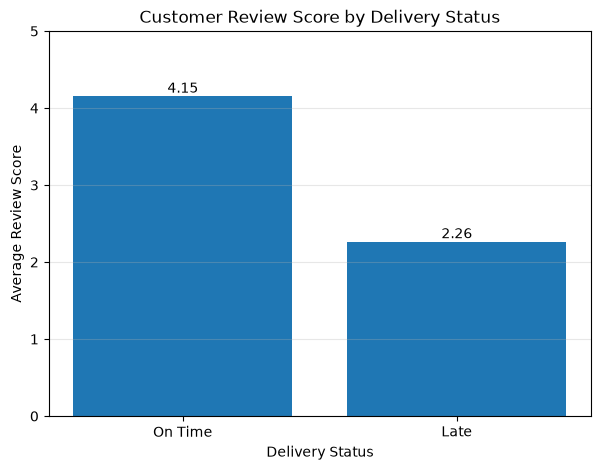

In [26]:
plt.figure(figsize=(7,5))

bars = plt.bar(
    delivery_reviews_plot["Delivery Status"],
    delivery_reviews_plot["Average_Review"]
)

plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.title("Customer Review Score by Delivery Status")

plt.ylim(0,5)

plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.05,
        f"{height:.2f}",
        ha="center"
    )

plt.show()

## Business Insight

Customers whose orders were delivered on time reported substantially higher review scores (4.15) compared to customers whose deliveries were late (2.26).

Although this analysis does not establish causation, it indicates a strong relationship between delivery performance and customer satisfaction.

Improving on-time delivery rates may help increase customer satisfaction and strengthen customer retention.